# 1 stock

In [14]:
import pandas as pd

df_stock = pd.read_csv("./data/^IXIC_history_2025-04-29.csv")
# df_stock.head()
print(df_stock[:1])

                        Date        Open        High         Low       Close  \
0  1985-01-02 00:00:00-05:00  247.100006  247.100006  245.899994  245.899994   

     Volume  Dividends  Stock Splits  
0  48210000        0.0           0.0  


In [7]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 6.0 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


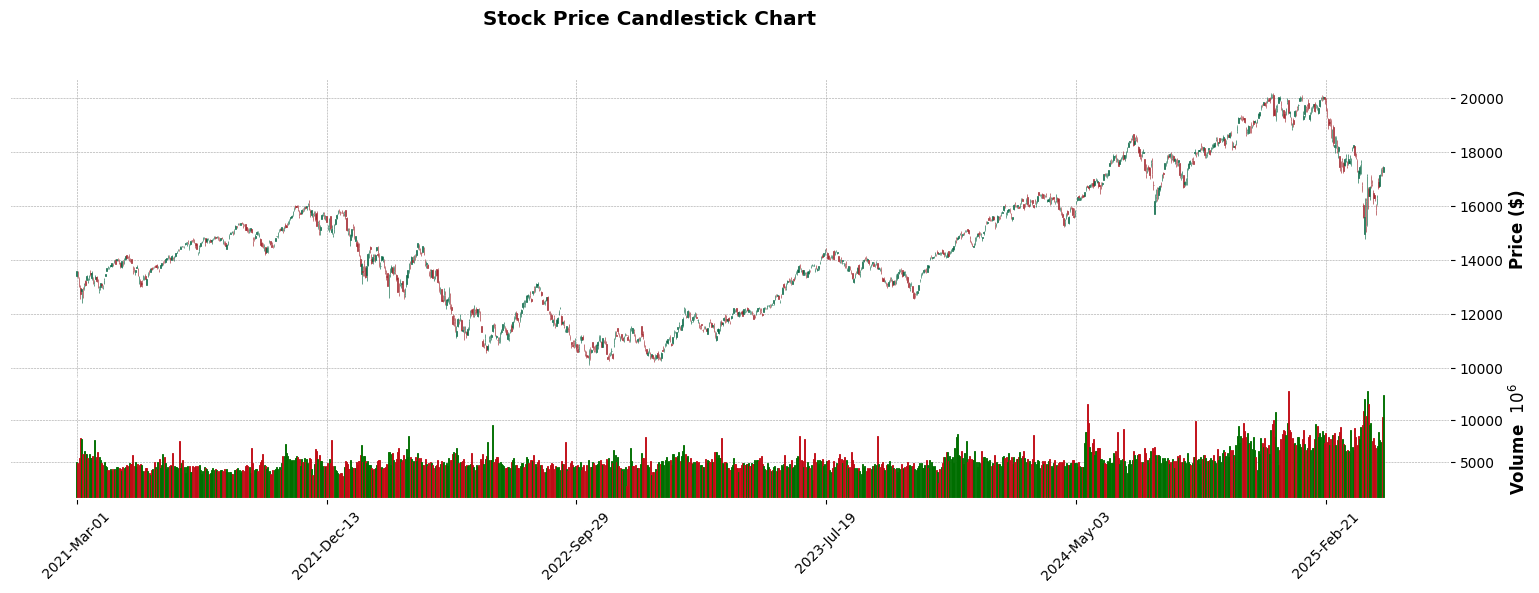

In [15]:
import pandas as pd
import mplfinance as mpf  # Please install mplfinance as follows: pip install mplfinance

df_stock = pd.read_csv("./data/^IXIC_history_2025-04-29.csv")

df_stock['Date'] = pd.to_datetime(df_stock['Date'], utc=True)

# Set 'Date' column as the index
df_stock.set_index('Date', inplace=True)

# df_stock = df_stock.tail(365*1)
df_stock = df_stock[df_stock.index >= pd.to_datetime('2021-03-01', utc=True)]

# Plot the candlestick chart
mpf.plot(df_stock, type='candlestick', style='charles', title='Stock Price Candlestick Chart', ylabel='Price ($)', figsize=(20, 6), volume=True)
# mpf.plot(df_stock, type='line', style='charles', title='Stock Price Line Chart', ylabel='Price ($)', figsize=(20, 6))
# mpf.plot(df_stock, type='line', style='charles', title='Stock Price Line Chart', ylabel='Price ($)', figsize=(20, 6), volume=True)

# 2 FG

In [16]:
import pandas as pd
import datetime

df_fg = pd.read_json('./data/fear_2021-03-01_2025-04-30.json')

fear_and_greed_historical_data = df_fg["fear_and_greed_historical"]["data"]
fear_and_greed_historical_data[:10]

import copy
fear_and_greed_historical_data_utc = copy.deepcopy(fear_and_greed_historical_data)

for i in range(len(fear_and_greed_historical_data_utc)):
  timestamp_ms = fear_and_greed_historical_data_utc[i]["x"]
  timestamp_s = timestamp_ms / 1000  # convert
  dt = datetime.datetime.utcfromtimestamp(timestamp_s)
  dt = str(dt)
  fear_and_greed_historical_data_utc[i]["x"] = dt

fear_and_greed_historical_data_utc[:1]

[{'x': '2021-03-01 00:00:00', 'y': 58.52, 'rating': 'greed'}]

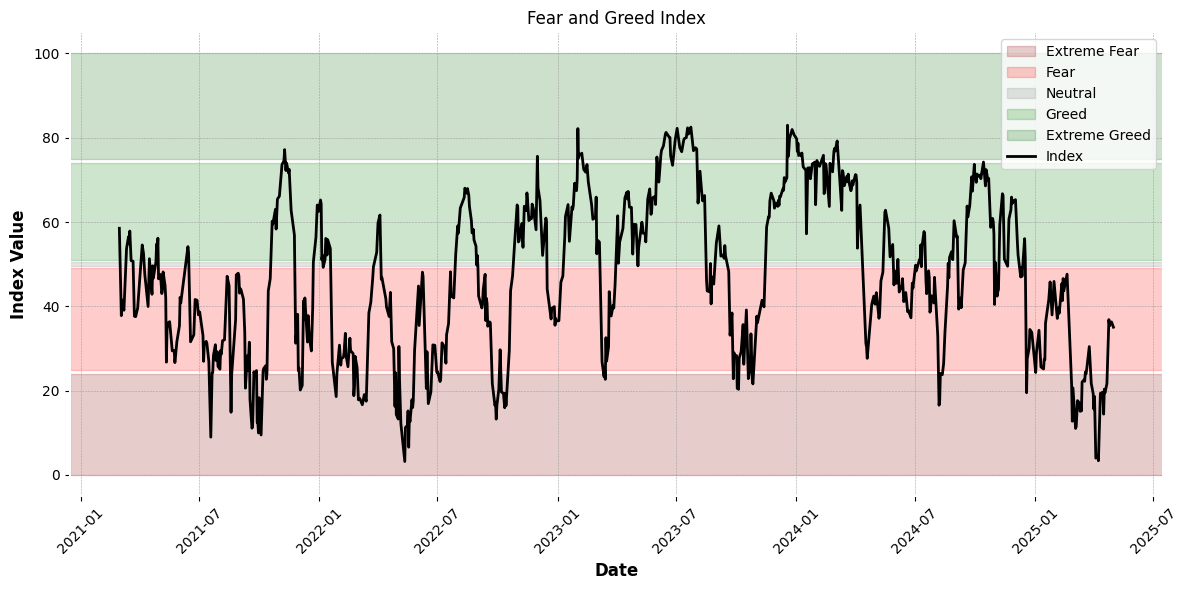

In [17]:
import matplotlib.pyplot as plt
from datetime import datetime

# x:date , y:sentiment score
dates = [datetime.strptime(item['x'], '%Y-%m-%d %H:%M:%S') for item in fear_and_greed_historical_data_utc]
values = [item['y'] for item in fear_and_greed_historical_data_utc]

# emotion range
def get_emotion_color(y):
    if y <= 24:
        return 'darkred', 'Extreme Fear'
    elif 25 <= y <= 49:
        return 'red', 'Fear'
    elif y == 50:
        return 'gray', 'Neutral'
    elif 51 <= y <= 74:
        return 'green', 'Greed'
    else:  # y >= 75
        return 'darkgreen', 'Extreme Greed'

colors = []
labels = []
for y in values:
    color, label = get_emotion_color(y)
    colors.append(color)
    labels.append(label)

########
fig, ax = plt.subplots(figsize=(12, 6))

# ax.axhspan to add a horizontal span (rectangle) across the Axes
emotion_zones = [
    (0, 24, 'Extreme Fear', 'darkred', 0.2),
    (25, 49, 'Fear', 'red', 0.2),
    (49.5, 50.5, 'Neutral', 'gray', 0.2),
    (51, 74, 'Greed', 'green', 0.2),
    (75, 100, 'Extreme Greed', 'darkgreen', 0.2),
]

for low, high, label, color, alpha in emotion_zones:
    ax.axhspan(low, high, color=color, alpha=alpha, label=label)

ax.plot(dates, values, color='black', label='Index')
ax.set_title('Fear and Greed Index')
ax.set_xlabel('Date')
ax.set_ylabel('Index Value')
ax.grid(True)
plt.xticks(rotation=45)

# create a legend ~
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()

## 3 merge
- df_stock[:1]
  - Date 2021-03-01 05:00:00+00:00
- df_stock[-1:]
  - Date 2025-04-29 04:00:00+00:00
- fear_and_greed_historical_data_utc[0]
  - {'x': '2021-03-01 00:00:00', 'y': 58.52, 'rating': 'greed'}
- fear_and_greed_historical_data_utc[-1]
  - {'x': '2025-04-30 23:59:51', 'y': 35.0571428571429, 'rating': 'fear'}

In [18]:
df_stock[:1]

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-03-01 05:00:00+00:00,13406.160156,13596.589844,13362.660156,13588.830078,5079530000,0.0,0.0


In [19]:
df_stock[-1:]

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-04-29 04:00:00+00:00,17270.759766,17500.419922,17256.199219,17461.320312,13001930000,0.0,0.0


In [20]:
fear_and_greed_historical_data_utc[0]

{'x': '2021-03-01 00:00:00', 'y': 58.52, 'rating': 'greed'}

In [21]:
fear_and_greed_historical_data_utc[-1]

{'x': '2025-04-30 23:59:51', 'y': 35.0571428571429, 'rating': 'fear'}

## 3.1 2021-03-01 ~ 2025-04-29

In [26]:
df_stock_range = df_stock['2021-03-01':'2025-04-29']
# df_stock_range.head()

df_fear_data = pd.DataFrame(fear_and_greed_historical_data_utc)
df_fear_data['x'] = pd.to_datetime(df_fear_data['x'])
df_fear_data.set_index('x', inplace=True)
df_fear_data_range = df_fear_data['2021-03-01':'2025-04-29']
# df_fear_data_range.head()

# uniform date
df_stock_range.index = df_stock_range.index.tz_localize(None).normalize()
df_fear_data_range.index = pd.to_datetime(df_fear_data_range.index).normalize()

df_merged = df_stock_range.join(df_fear_data_range, how='inner')
# df_merged.head()
df_merged.index.name = 'Date'
df_merged.to_csv('./data/^IXIC_fear_merged_2021-03-01_2025-04-29.csv', index=True)

## 3.2 2021-03-01 ~ 2023-03-01

In [27]:
df_stock_range = df_stock['2021-03-01':'2023-03-01']
# df_stock_range.head()

df_fear_data = pd.DataFrame(fear_and_greed_historical_data_utc)
df_fear_data['x'] = pd.to_datetime(df_fear_data['x'])
df_fear_data.set_index('x', inplace=True)
df_fear_data_range = df_fear_data['2021-03-01':'2023-03-01']
# df_fear_data_range.head()

# uniform date
df_stock_range.index = df_stock_range.index.tz_localize(None).normalize()
df_fear_data_range.index = pd.to_datetime(df_fear_data_range.index).normalize()

df_merged = df_stock_range.join(df_fear_data_range, how='inner')
# df_merged.head()
df_merged.index.name = 'Date'
df_merged.to_csv('./data/^IXIC_fear_merged_2021-03-01_2023-03-01.csv', index=True)